<a href="https://colab.research.google.com/github/Namain231/GA_Task_Scheduler/blob/main/GA_Task_Scheduler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded. Ready to build the scheduler.")

Libraries loaded. Ready to build the scheduler.


In [ ]:
# 1.Graph
dag = nx.DiGraph()

# 2. Processor Execution Times {Task: [P1, P2, P3]}
execution_matrix = {
    1: [14, 16, 9], 2: [13, 19, 18], 3: [11, 13, 19],
    4: [13, 8, 17], 5: [12, 13, 10], 6: [13, 16, 9],
    7: [7, 15, 11], 8: [5, 11, 14], 9: [18, 12, 20],
    10: [21, 7, 16]
}
for task_id in execution_matrix.keys():
    dag.add_node(task_id)

# 3. Communication Costs (Edges)
edges = [
    (1,2,18), (1,3,12), (1,4,9), (1,5,11), (1,6,14),
    (2,8,19), (2,9,16), (3,7,23), (4,8,27), (4,9,23),
    (5,9,13), (6,8,15), (7,10,17), (8,10,11), (9,10,13)
]
for u, v, w in edges:
    dag.add_edge(u, v, weight=w)

print("Validation DAG loaded. Target HEFT Makespan to beat: 80.")

Validation DAG loaded. Target HEFT Makespan to beat: 80.


In [ ]:
def calculate_upward_rank(dag, execution_matrix):
    """
    Phase 1 of HEFT: Calculates the upward rank of every task.
    Rank is based on average computation cost + maximum communication cost to children.
    """
    # 4. Avg computation cost for each task across all processors
    avg_comp_costs = {
        task: sum(times) / len(times)
        for task, times in execution_matrix.items()
    }

    ranks = {}

    # 5. Recursive function to traverse from exit nodes up to entry nodes
    def compute_rank(node):
        if node in ranks:
            return ranks[node]

        successors = list(dag.successors(node))

        #6. Exit node (no children)
        if not successors:
            ranks[node] = avg_comp_costs[node]
        else:
            #7. Find the path with the highest cost through children
            max_succ_cost = 0
            for succ in successors:
                comm_cost = dag[node][succ]['weight']
                child_rank = compute_rank(succ)
                if comm_cost + child_rank > max_succ_cost:
                    max_succ_cost = comm_cost + child_rank

            ranks[node] = avg_comp_costs[node] + max_succ_cost

        return ranks[node]

    #8. All nodes' ranks
    for node in dag.nodes():
        compute_rank(node)

    return ranks


def heft_scheduler(dag, execution_matrix, ranks):
    """
    Phase 2 of HEFT: Greedily assigns tasks to the processor that
    minimizes the Earliest Finish Time (EFT).
    """
    #9. Sorting tasks; Upward rank, descending order
    sorted_tasks = sorted(ranks.keys(), key=lambda k: ranks[k], reverse=True)

    num_processors = len(list(execution_matrix.values())[0])
    processor_avail_time = {i: 0 for i in range(num_processors)}

    task_finish_times = {}
    task_processor_map = {}
    schedule = []

    for task in sorted_tasks:
        best_finish_time = float('inf')
        best_start_time = -1
        best_processor = -1

        #10. Test the task on every available processor
        for p in range(num_processors):
            max_parent_avail = 0

            for parent in dag.predecessors(task):
                parent_proc = task_processor_map[parent]
                parent_finish = task_finish_times[parent]

                #11. Dynamic Delay Logic: If on the same processor, delay is 0. Else, add the edge weight.
                delay = 0 if p == parent_proc else dag[parent][task]['weight']

                #12. The data from THIS parent is ready at this time:
                data_arrival_time = parent_finish + delay
                if data_arrival_time > max_parent_avail:
                    max_parent_avail = data_arrival_time

            #13. The task can only start when BOTH the processor is free AND all data arrived
            start_time = max(processor_avail_time[p], max_parent_avail)
            finish_time = start_time + execution_matrix[task][p]

            #14. Update best processor if fastest finish
            if finish_time < best_finish_time:
                best_finish_time = finish_time
                best_start_time = start_time
                best_processor = p

        #15. Commit the task to the best processor
        processor_avail_time[best_processor] = best_finish_time
        task_finish_times[task] = best_finish_time
        task_processor_map[task] = best_processor

        schedule.append({
            "task": task,
            "processor": best_processor,
            "start": best_start_time,
            "finish": best_finish_time
        })

    #16. The Makespan is simply the time the busiest processor finally finishes
    makespan = max(processor_avail_time.values())

    return schedule, makespan

print("HEFT logic loaded successfully.")

HEFT logic loaded successfully.


In [ ]:
ranks = calculate_upward_rank(dag, execution_matrix)

#17.HEFT scheduler
heft_schedule, heft_makespan = heft_scheduler(dag, execution_matrix, ranks)

print(f"Validation Result - HEFT Makespan: {heft_makespan}")


Validation Result - HEFT Makespan: 80


In [ ]:

def generate_topological_chromosome(fixed_task_order, num_processors):
    """
    18. Generates a legal chromosome (list of processor assignments) based on
    a predefined topological order.
    """
    chromosome_processors = []
    for _ in fixed_task_order: #18. Get length of fixed-order tasks
        assigned_proc = random.randint(0, num_processors - 1)
        chromosome_processors.append(assigned_proc)
    return chromosome_processors


def evaluate_makespan_ga(chromosome_processors, dag, execution_matrix, fixed_task_order):
    """
    19. Simulates the schedule defined by the chromosome (list of processor assignments)
    and calculates the Makespan.
    Applies the communication delay (c_ij) if parent and child are on different processors.
    """
    num_processors = len(list(execution_matrix.values())[0])
    processor_avail_time = {i: 0 for i in range(num_processors)}

    task_finish_times = {}
    task_processor_map = {}

    for i, proc in enumerate(chromosome_processors):
        task = fixed_task_order[i]

        max_parent_avail = 0

        #20. Check all dependencies for the current task
        for parent in dag.predecessors(task):
            #21 The fixed_task_order ensures parents are scheduled before children so 'parent' should always be in task_processor_map at this point.
            parent_proc = task_processor_map[parent]
            parent_finish = task_finish_times[parent]

            #22. Communication delay penalty
            delay = 0 if proc == parent_proc else dag[parent][task]['weight']

            data_arrival_time = parent_finish + delay
            if data_arrival_time > max_parent_avail:
                max_parent_avail = data_arrival_time

        #23. Task starts when the processor is free AND all parent data has arrived
        start_time = max(processor_avail_time[proc], max_parent_avail)
        finish_time = start_time + execution_matrix[task][proc]

        #24. Update trackers
        processor_avail_time[proc] = finish_time
        task_finish_times[task] = finish_time
        task_processor_map[task] = proc

    return max(processor_avail_time.values())


def calculate_fitness(makespan):
    """
    25. Fitness is inversely proportional to Makespan.
    Lower Makespan = Higher Fitness.
    """
    return 1.0 / makespan


def crossover(parent1_processors, parent2_processors):
    """
    26. Single-point crossover that respects topological boundaries by swapping
    processor assignments at corresponding positions.
    """
    crossover_point = random.randint(1, len(parent1_processors) - 2)

    child1_processors = parent1_processors[:crossover_point] + parent2_processors[crossover_point:]
    child2_processors = parent2_processors[:crossover_point] + parent1_processors[crossover_point:]

    return child1_processors, child2_processors


def mutate(chromosome_processors, num_processors, mutation_rate=0.1):
    """
    27. Randomly changes the processor assignment of a task at a given position.
    """
    mutated_chromosome_processors = list(chromosome_processors)

    for i in range(len(mutated_chromosome_processors)):
        if random.random() < mutation_rate:
            current_proc = mutated_chromosome_processors[i]
            choices = [p for p in range(num_processors) if p != current_proc]
            if choices: #28. Ensure there are other processors to choose from
                mutated_chromosome_processors[i] = random.choice(choices)

    return mutated_chromosome_processors

print("Genetic Algorithm functions loaded.")

Genetic Algorithm functions loaded.


In [ ]:
#29. --- SIMULATION PARAMETERS ---
POPULATION_SIZE = 50
GENERATIONS = 100
MUTATION_RATE = 0.1
NUM_PROCESSORS = 3

#30. We will save the best makespan of each generation to plot the Convergence Graph later
convergence_history = []

#31. Define a fixed topological order for all chromosomes
fixed_task_order = list(nx.topological_sort(dag))

#32. HEFT BASELINE
ranks = calculate_upward_rank(dag, execution_matrix)
heft_schedule, heft_makespan = heft_scheduler(dag, execution_matrix, ranks)
print(f"--- BASELINE HEFT MAKESPAN: {heft_makespan} ---")

#33. Convert HEFT output into a GA-compatible chromosome (list of processor assignments based on the fixed_task_order).
heft_processor_map = {item["task"]: item["processor"] for item in heft_schedule}
heft_chromosome_processors = [heft_processor_map[task] for task in fixed_task_order]

#34. INITIALIZE POPULATION (The Hybrid Seed)
population = [generate_topological_chromosome(fixed_task_order, NUM_PROCESSORS) for _ in range(POPULATION_SIZE - 1)]
population.append(heft_chromosome_processors) # INJECTING HEFT AS THE SEED

#35. THE EVOLUTION LOOP
for gen in range(GENERATIONS):
    #36. Evaluate all chromosomes
    scored_population = []
    for chromo_processors in population:
        mkspan = evaluate_makespan_ga(chromo_processors, dag, execution_matrix, fixed_task_order)
        fit = calculate_fitness(mkspan)
        scored_population.append((chromo_processors, fit, mkspan))

    #37. Sort by fitness (highest first)
    scored_population.sort(key=lambda x: x[1], reverse=True)

    #38. Record the best makespan of this generation
    best_current_makespan = scored_population[0][2]
    convergence_history.append(best_current_makespan)

    #39. Elitism: Keep the best 10% of the population automatically
    elite_count = int(0.1 * POPULATION_SIZE)
    new_population = [item[0] for item in scored_population[:elite_count]]

    #40. Rest of the new generation with Crossover & Mutation
    while len(new_population) < POPULATION_SIZE:
        #41. Tournament Selection (Pick two random parents, take the better one)
        p1_processors = max(random.sample(scored_population, 3), key=lambda x: x[1])[0]
        p2_processors = max(random.sample(scored_population, 3), key=lambda x: x[1])[0]

        #42. Reproduce
        child1_processors, child2_processors = crossover(p1_processors, p2_processors)

        #43. Mutate
        child1_processors = mutate(child1_processors, NUM_PROCESSORS, MUTATION_RATE)

        new_population.append(child1_processors)
        if len(new_population) < POPULATION_SIZE:
            child2_processors = mutate(child2_processors, NUM_PROCESSORS, MUTATION_RATE)
            new_population.append(child2_processors)

    population = new_population

#44. FINAL RESULTS
final_best_makespan = convergence_history[-1]
print(f"--- FINAL GA OPTIMIZED MAKESPAN: {final_best_makespan} ---")
print(f"Improvement over HEFT: {heft_makespan - final_best_makespan} time units.")

--- BASELINE HEFT MAKESPAN: 80 ---
--- FINAL GA OPTIMIZED MAKESPAN: 76 ---
Improvement over HEFT: 4 time units.


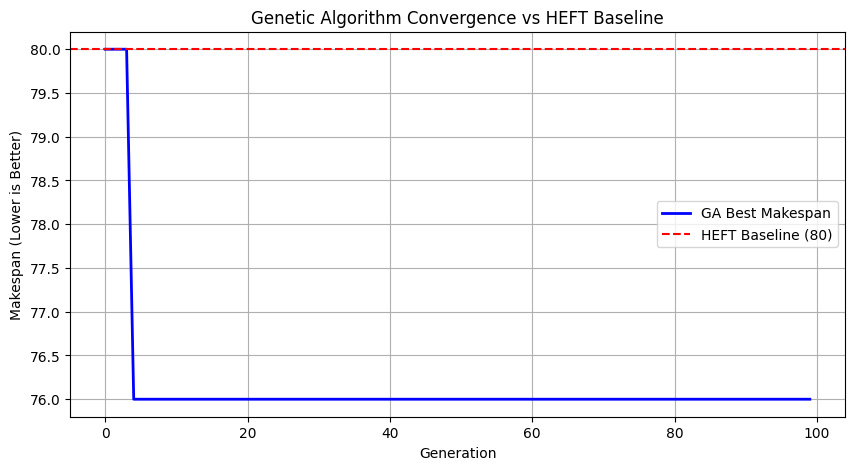

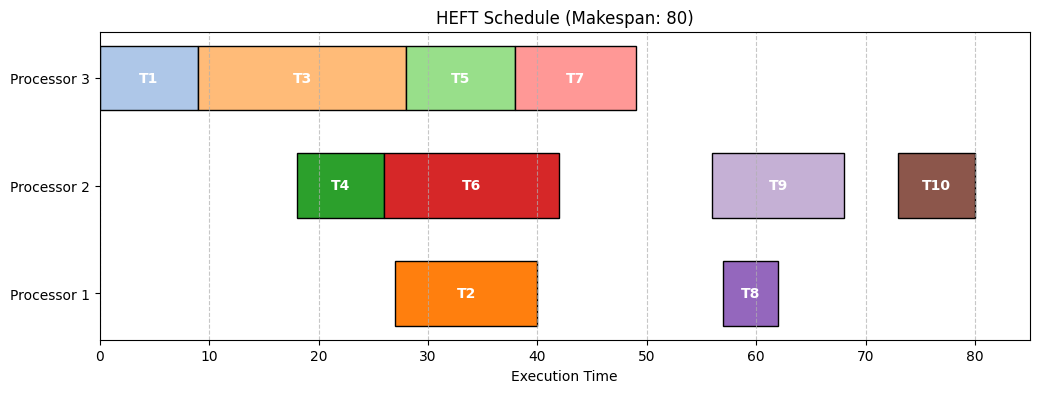

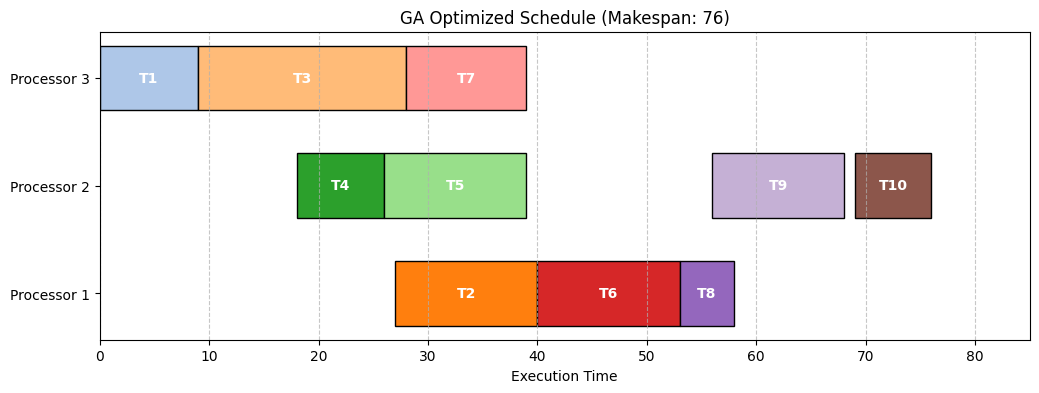

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#45. Helper Function to reconstruct the schedule from the winning chromosome
def decode_chromosome_to_schedule(chromosome_processors, dag, execution_matrix, fixed_task_order):
    num_processors = len(list(execution_matrix.values())[0])
    processor_avail_time = {i: 0 for i in range(num_processors)}
    task_finish_times = {}
    task_processor_map = {}
    schedule = []

    for i, proc in enumerate(chromosome_processors):
        task = fixed_task_order[i]
        max_parent_avail = 0

        for parent in dag.predecessors(task):
            parent_proc = task_processor_map[parent]
            parent_finish = task_finish_times[parent]
            delay = 0 if proc == parent_proc else dag[parent][task]['weight']
            if parent_finish + delay > max_parent_avail:
                max_parent_avail = parent_finish + delay

        start_time = max(processor_avail_time[proc], max_parent_avail)
        finish_time = start_time + execution_matrix[task][proc]

        processor_avail_time[proc] = finish_time
        task_finish_times[task] = finish_time
        task_processor_map[task] = proc

        schedule.append({"task": task, "processor": proc, "start": start_time, "finish": finish_time})

    return schedule

#46. Get the best chromosome from the end of the GA loop (assuming population is sorted)
best_ga_chromosome = population[0]
ga_schedule = decode_chromosome_to_schedule(best_ga_chromosome, dag, execution_matrix, fixed_task_order)

#47. PLOT 1: Convergence History
plt.figure(figsize=(10, 5))
plt.plot(range(len(convergence_history)), convergence_history, color='blue', linewidth=2, label="GA Best Makespan")
plt.axhline(y=heft_makespan, color='red', linestyle='--', label=f"HEFT Baseline ({heft_makespan})")
plt.title("Genetic Algorithm Convergence vs HEFT Baseline")
plt.xlabel("Generation")
plt.ylabel("Makespan (Lower is Better)")
plt.legend()
plt.grid(True)
plt.show()

#48. PLOT 2: Gantt Chart Generator
def plot_gantt(schedule, title, max_time):
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = plt.cm.tab20.colors

    for item in schedule:
        task = item["task"]
        p = item["processor"]
        start = item["start"]
        finish = item["finish"]
        duration = finish - start

        ax.barh(p, duration, left=start, color=colors[task % 20], edgecolor='black', height=0.6)
        ax.text(start + duration/2, p, f"T{task}", ha='center', va='center', color='white', fontweight='bold')

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Processor 1', 'Processor 2', 'Processor 3'])
    ax.set_xlabel('Execution Time')
    ax.set_xlim(0, max_time + 5)
    ax.set_title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

plot_gantt(heft_schedule, f"HEFT Schedule (Makespan: {heft_makespan})", heft_makespan)
plot_gantt(ga_schedule, f"GA Optimized Schedule (Makespan: {final_best_makespan})", heft_makespan)

Further below are individual evaluations and calculations performed again on various aspects of the project so far.

Upward Rank Table

In [ ]:
ranks = calculate_upward_rank(dag, execution_matrix)

avg_comp_costs = {
    task: round(sum(times) / len(times), 2)
    for task, times in execution_matrix.items()
}

print("Upward Rank Table")
print(f"{'Task':<8} {'Avg Exec Cost':<18} {'Upward Rank':>12}")
print("-" * 40)
for task in sorted(ranks.keys()):
    print(f"  T{task:<6} {avg_comp_costs[task]:<18.2f} {ranks[task]:>12.2f}")

print(f"\nTask T{max(ranks, key=ranks.get)} has the highest rank "
      f"({max(ranks.values()):.2f}) so it gets scheduled first.")
print(f"Task T{min(ranks, key=ranks.get)} has the lowest rank "
      f"({min(ranks.values()):.2f}) and goes last.")

Upward Rank Table
Task     Avg Exec Cost       Upward Rank
----------------------------------------
  T1      13.00                    108.00
  T2      16.67                     77.00
  T3      14.33                     80.00
  T4      12.67                     80.00
  T5      11.67                     69.00
  T6      12.67                     63.33
  T7      11.00                     42.67
  T8      10.00                     35.67
  T9      16.67                     44.33
  T10     14.67                     14.67

Task T1 has the highest rank (108.00) so it gets scheduled first.
Task T10 has the lowest rank (14.67) and goes last.


HEFT Schedule Table

In [ ]:
print("HEFT Schedule")
print(f"{'Task':<8} {'Processor':<14} {'Start':<12} {'Finish':<12} {'Duration'}")
print("-" * 56)

for item in sorted(heft_schedule, key=lambda x: x["start"]):
    t   = item["task"]
    p   = item["processor"] + 1
    s   = item["start"]
    f   = item["finish"]
    dur = f - s
    print(f"  T{t:<6}  P{p:<12}  {s:<12}  {f:<12}  {dur}")

print(f"\nHEFT total makespan = {heft_makespan} time units")

HEFT Schedule
Task     Processor      Start        Finish       Duration
--------------------------------------------------------
  T1       P3             0             9             9
  T3       P3             9             28            19
  T4       P2             18            26            8
  T6       P2             26            42            16
  T2       P1             27            40            13
  T5       P3             28            38            10
  T7       P3             38            49            11
  T9       P2             56            68            12
  T8       P1             57            62            5
  T10      P2             73            80            7

HEFT total makespan = 80 time units


GA Optimized Schedule Table

In [ ]:
print("GA Optimized Schedule")
print(f"{'Task':<8} {'Processor':<14} {'Start':<12} {'Finish':<12} {'Duration'}")
print("-" * 56)

for item in sorted(ga_schedule, key=lambda x: x["start"]):
    t   = item["task"]
    p   = item["processor"] + 1
    s   = item["start"]
    f   = item["finish"]
    dur = f - s
    print(f"  T{t:<6}  P{p:<12}  {s:<12}  {f:<12}  {dur}")

print(f"\nGA total makespan = {final_best_makespan} time units")

GA Optimized Schedule
Task     Processor      Start        Finish       Duration
--------------------------------------------------------
  T1       P3             0             9             9
  T3       P3             9             28            19
  T4       P2             18            26            8
  T5       P2             26            39            13
  T2       P1             27            40            13
  T7       P3             28            39            11
  T6       P1             40            53            13
  T8       P1             53            58            5
  T9       P2             56            68            12
  T10      P2             69            76            7

GA total makespan = 76 time units


Comparison Table

In [ ]:
def compute_utilization(schedule, makespan):
    busy = {0: 0, 1: 0, 2: 0}
    for item in schedule:
        busy[item["processor"]] += (item["finish"] - item["start"])
    return {p: round(busy[p] / makespan * 100, 1) for p in busy}

heft_util = compute_utilization(heft_schedule, heft_makespan)
ga_util   = compute_utilization(ga_schedule, final_best_makespan)

improvement     = heft_makespan - final_best_makespan
improvement_pct = (improvement / heft_makespan) * 100
best_ever       = min(convergence_history)

heft_imbalance = max(heft_util.values()) - min(heft_util.values())
ga_imbalance   = max(ga_util.values())   - min(ga_util.values())

print(f"  {'Metric':<35} {'HEFT':>10}  {'GA':>10}")
print(f"  {'-'*55}")
print(f"  {'Makespan (time units)':<35} {heft_makespan:>10}  {final_best_makespan:>10}")
print(f"  {'Best makespan across all generations':<35} {heft_makespan:>10}  {best_ever:>10}")
print(f"  {'Improvement (time units)':<35} {'—':>10}  {improvement:>10}")
print(f"  {'Improvement (%)':<35} {'—':>10}  {improvement_pct:>9.1f}%")
print(f"  {'P1 utilization':<35} {heft_util[0]:>9}%  {ga_util[0]:>9}%")
print(f"  {'P2 utilization':<35} {heft_util[1]:>9}%  {ga_util[1]:>9}%")
print(f"  {'P3 utilization':<35} {heft_util[2]:>9}%  {ga_util[2]:>9}%")
print(f"  {'Load imbalance':<35} {heft_imbalance:>9}%  {ga_imbalance:>9}%")

if improvement > 0:
    print(f"\nGA beat HEFT by {improvement} time units ({improvement_pct:.1f}% faster).")
elif improvement == 0:
    print("\nGA matched HEFT - same makespan, no improvement this run.")
else:
    print("\nGA did not improve over HEFT in this run.")

  Metric                                    HEFT          GA
  -------------------------------------------------------
  Makespan (time units)                       80          76
  Best makespan across all generations         80          76
  Improvement (time units)                     —           4
  Improvement (%)                              —        5.0%
  P1 utilization                           22.5%       40.8%
  P2 utilization                           53.8%       52.6%
  P3 utilization                           61.3%       51.3%
  Load imbalance                           38.8%  11.800000000000004%

GA beat HEFT by 4 time units (5.0% faster).


Chromosome Comparison

In [ ]:
heft_proc_map = {item["task"]: item["processor"] for item in heft_schedule}
heft_chrom    = [heft_proc_map[t] for t in fixed_task_order]
ga_chrom      = list(best_ga_chromosome)

print("Chromosome Comparison")
print(f"Task order :      {fixed_task_order}")
print(f"HEFT assignment:  {heft_chrom}   (0=P1, 1=P2, 2=P3)")
print(f"GA assignment:    {ga_chrom}")

changed = [fixed_task_order[i] for i in range(len(heft_chrom))
           if heft_chrom[i] != ga_chrom[i]]

if changed:
    print(f"\nTasks reassigned by GA: {changed}")
    print("These are the positions where GA chose a different processor than HEFT.")
else:
    print("\nGA converged to exactly the same assignment as HEFT.")

Chromosome Comparison
Task order :      [1, 2, 3, 4, 5, 6, 7, 9, 8, 10]
HEFT assignment:  [2, 0, 2, 1, 2, 1, 2, 1, 0, 1]   (0=P1, 1=P2, 2=P3)
GA assignment:    [2, 0, 2, 1, 1, 0, 2, 1, 0, 1]

Tasks reassigned by GA: [5, 6]
These are the positions where GA chose a different processor than HEFT.


Convergence Statistics

In [ ]:
gen_of_best   = convergence_history.index(min(convergence_history))
stagnant_gens = sum(1 for i in range(1, len(convergence_history))
                    if convergence_history[i] == convergence_history[i-1])

print("GA Convergence Summary")
print(f"  Starting makespan (Gen 0) :  {convergence_history[0]}")
print(f"  Final makespan   (Gen 99) :  {convergence_history[-1]}")
print(f"  Best makespan found       :  {min(convergence_history)} at generation {gen_of_best}")
print(f"  Generations with no change:  {stagnant_gens} out of {len(convergence_history)}")

GA Convergence Summary
  Starting makespan (Gen 0) :  80
  Final makespan   (Gen 99) :  76
  Best makespan found       :  76 at generation 4
  Generations with no change:  98 out of 100


Communication Cost Breakdown

In [ ]:
def get_comm_costs(schedule, dag):
    proc_map = {item["task"]: item["processor"] for item in schedule}
    results  = []
    total    = 0
    for u, v, data in dag.edges(data=True):
        w      = data["weight"]
        same   = proc_map[u] == proc_map[v]
        cost   = 0 if same else w
        total += cost
        results.append({"edge": f"T{u}->T{v}", "weight": w,
                         "same": same, "cost": cost})
    return results, total

heft_comm, heft_total_comm = get_comm_costs(heft_schedule, dag)
ga_comm,   ga_total_comm   = get_comm_costs(ga_schedule, dag)

print("Communication Cost Breakdown")
print(f"{'Edge':<10} {'Edge Weight':<14} {'HEFT Cost':<22} {'GA Cost'}")
print("-" * 60)
for h, g in zip(heft_comm, ga_comm):
    hc = "0  (same proc)" if h["same"] else str(h["cost"])
    gc = "0  (same proc)" if g["same"] else str(g["cost"])
    print(f"  {h['edge']:<8}  {h['weight']:<14}  {hc:<22}  {gc}")
print("-" * 60)
print(f"  {'TOTAL':<22}  {heft_total_comm:<22}  {ga_total_comm}")
print(f"\nGA saved {heft_total_comm - ga_total_comm} time units in communication overhead.")

Communication Cost Breakdown
Edge       Edge Weight    HEFT Cost              GA Cost
------------------------------------------------------------
  T1->T2    18              18                      18
  T1->T3    12              0  (same proc)          0  (same proc)
  T1->T4    9               9                       9
  T1->T5    11              0  (same proc)          11
  T1->T6    14              14                      14
  T2->T8    19              0  (same proc)          0  (same proc)
  T2->T9    16              16                      16
  T3->T7    23              0  (same proc)          0  (same proc)
  T4->T8    27              27                      27
  T4->T9    23              0  (same proc)          0  (same proc)
  T5->T9    13              13                      0  (same proc)
  T6->T8    15              15                      0  (same proc)
  T7->T10   17              17                      17
  T8->T10   11              11                      11
  T9->T10   

Convergence Plot

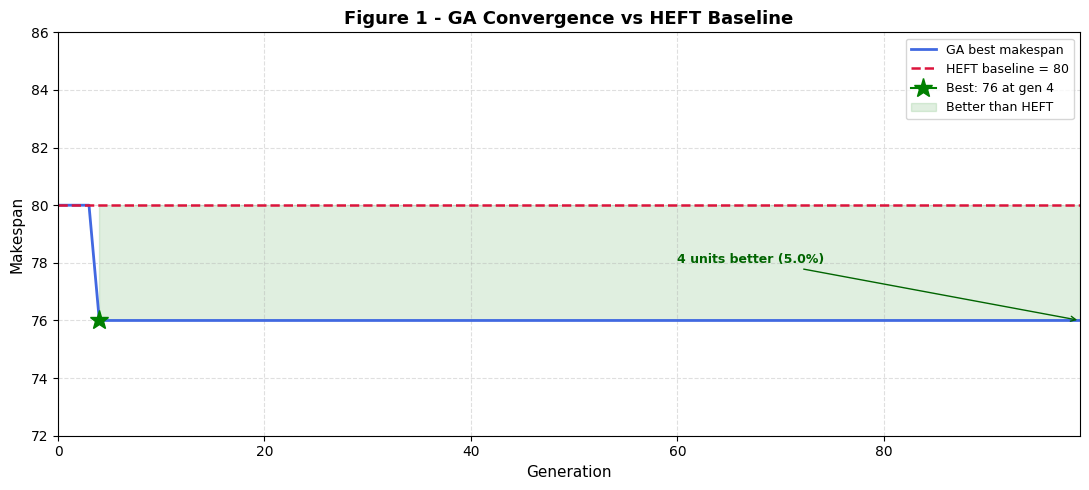

In [ ]:
fig1, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(range(len(convergence_history)), convergence_history,
         color='royalblue', linewidth=2, label="GA best makespan")

ax1.axhline(y=heft_makespan, color='crimson', linestyle='--',
            linewidth=1.8, label=f"HEFT baseline = {heft_makespan}")

ax1.plot(gen_of_best, min(convergence_history),
         marker='*', markersize=14, color='green', zorder=4,
         label=f"Best: {min(convergence_history)} at gen {gen_of_best}")

ax1.fill_between(
    range(len(convergence_history)),
    convergence_history,
    heft_makespan,
    where=[v < heft_makespan for v in convergence_history],
    alpha=0.12, color='green', label="Better than HEFT"
)

if improvement > 0:
    ax1.annotate(
        f"{improvement} units better ({improvement_pct:.1f}%)",
        xy=(len(convergence_history)-1, final_best_makespan),
        xytext=(len(convergence_history)*0.6, (heft_makespan + final_best_makespan)/2),
        fontsize=9, color='darkgreen', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='darkgreen')
    )

ax1.set_title("Figure 1 - GA Convergence vs HEFT Baseline", fontsize=13, fontweight='bold')
ax1.set_xlabel("Generation", fontsize=11)
ax1.set_ylabel("Makespan", fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_xlim(0, len(convergence_history) - 1)
ax1.set_ylim(min(convergence_history) - 4, heft_makespan + 6)

plt.tight_layout()
plt.savefig("fig1_convergence.png", dpi=150, bbox_inches='tight')
plt.show()

Gantt Charts

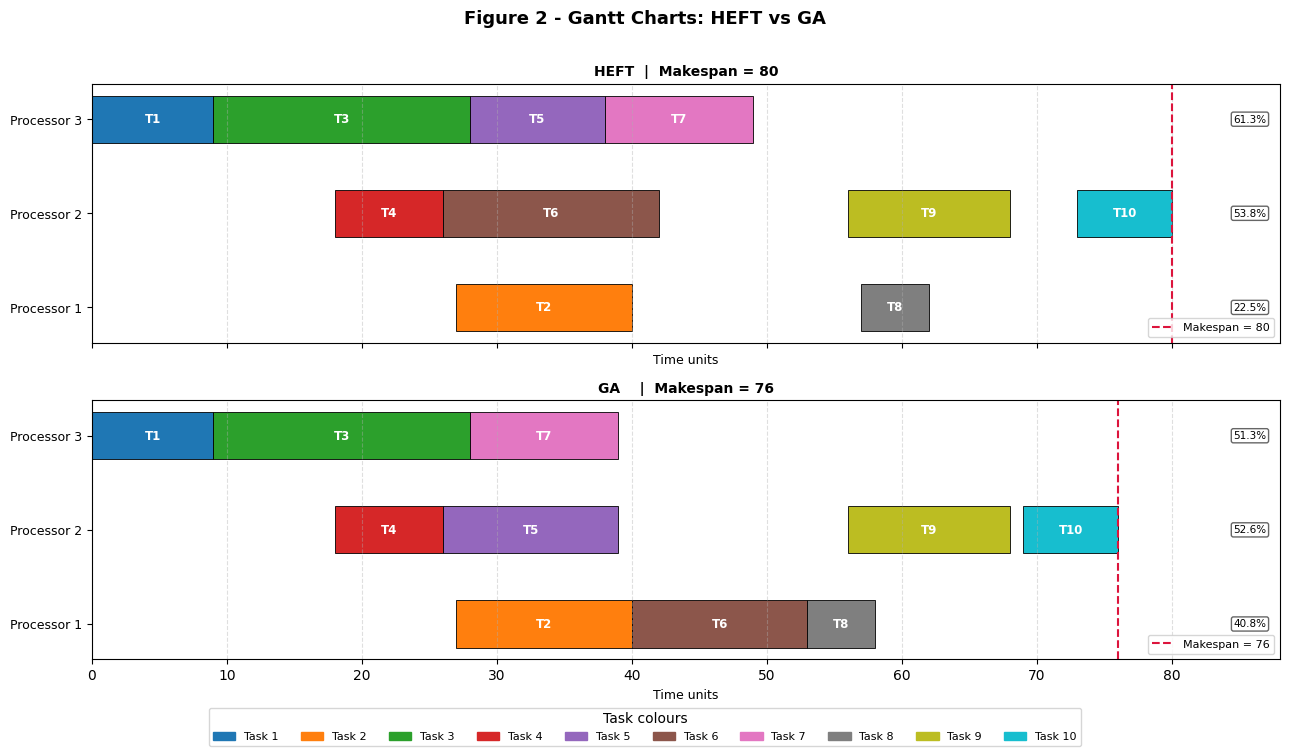

In [ ]:
TASK_COLORS = plt.cm.tab10.colors

def draw_gantt(ax, schedule, title, makespan_val):
    for item in schedule:
        t   = item["task"]
        p   = item["processor"]
        s   = item["start"]
        f   = item["finish"]
        dur = f - s
        ax.barh(p, dur, left=s,
                color=TASK_COLORS[(t-1) % 10],
                edgecolor='black', linewidth=0.6, height=0.5)
        if dur >= 4:
            ax.text(s + dur/2, p, f"T{t}",
                    ha='center', va='center',
                    color='white', fontsize=8.5, fontweight='bold')

    ax.axvline(x=makespan_val, color='crimson',
               linestyle='--', linewidth=1.5,
               label=f"Makespan = {makespan_val}")
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Processor 1', 'Processor 2', 'Processor 3'], fontsize=9)
    ax.set_xlabel("Time units", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlim(0, max(heft_makespan, final_best_makespan) + 8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='lower right')

    util = compute_utilization(schedule, makespan_val)
    for p in range(3):
        ax.text(ax.get_xlim()[1] - 1, p, f"{util[p]}%",
                ha='right', va='center', fontsize=7.5,
                bbox=dict(boxstyle='round,pad=0.2',
                          facecolor='white', alpha=0.6))

fig2, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig2.suptitle("Figure 2 - Gantt Charts: HEFT vs GA",
              fontsize=13, fontweight='bold', y=1.01)

draw_gantt(ax_top, heft_schedule,
           f"HEFT  |  Makespan = {heft_makespan}", heft_makespan)
draw_gantt(ax_bot, ga_schedule,
           f"GA    |  Makespan = {final_best_makespan}", final_best_makespan)

legend_patches = [
    mpatches.Patch(color=TASK_COLORS[(t-1) % 10], label=f"Task {t}")
    for t in sorted(execution_matrix.keys())
]
fig2.legend(handles=legend_patches, loc='lower center', ncol=10,
            fontsize=8, bbox_to_anchor=(0.5, -0.05), title="Task colours")

plt.tight_layout()
plt.savefig("fig2_gantt.png", dpi=150, bbox_inches='tight')
plt.show()

Processor Utilization Bar Chart

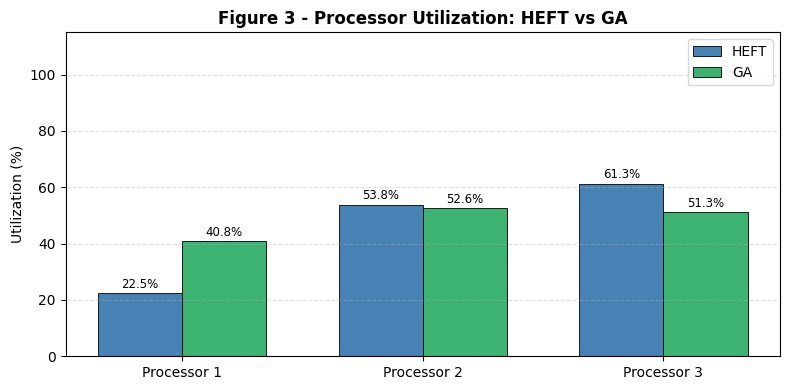

In [ ]:
fig3, ax3 = plt.subplots(figsize=(8, 4))

procs  = ['Processor 1', 'Processor 2', 'Processor 3']
heft_v = [heft_util[0], heft_util[1], heft_util[2]]
ga_v   = [ga_util[0],   ga_util[1],   ga_util[2]]
x      = np.arange(3)
w      = 0.35

b1 = ax3.bar(x - w/2, heft_v, w, label='HEFT',
             color='steelblue', edgecolor='black', linewidth=0.6)
b2 = ax3.bar(x + w/2, ga_v,   w, label='GA',
             color='mediumseagreen', edgecolor='black', linewidth=0.6)

for bar in b1:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8,
             f"{bar.get_height():.1f}%",
             ha='center', va='bottom', fontsize=8.5)
for bar in b2:
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8,
             f"{bar.get_height():.1f}%",
             ha='center', va='bottom', fontsize=8.5)

ax3.set_ylabel("Utilization (%)", fontsize=10)
ax3.set_title("Figure 3 - Processor Utilization: HEFT vs GA",
              fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(procs, fontsize=10)
ax3.set_ylim(0, 115)
ax3.legend(fontsize=10)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("fig3_utilization.png", dpi=150, bbox_inches='tight')
plt.show()

Communication Costs Per Edge

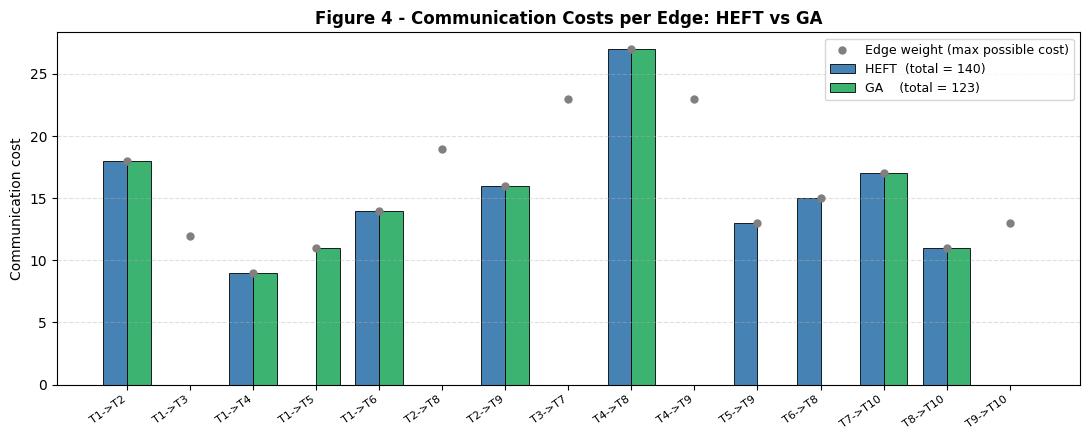

In [ ]:
fig4, ax4 = plt.subplots(figsize=(11, 4.5))

elabels = [e["edge"]  for e in heft_comm]
hcosts  = [e["cost"]  for e in heft_comm]
gcosts  = [e["cost"]  for e in ga_comm]
x2      = np.arange(len(elabels))
w2      = 0.38

ax4.bar(x2 - w2/2, hcosts, w2,
        label=f"HEFT  (total = {heft_total_comm})",
        color='steelblue', edgecolor='black', linewidth=0.6)
ax4.bar(x2 + w2/2, gcosts, w2,
        label=f"GA    (total = {ga_total_comm})",
        color='mediumseagreen', edgecolor='black', linewidth=0.6)

ax4.scatter(x2, [e["weight"] for e in heft_comm],
            color='gray', zorder=3, s=25,
            label="Edge weight (max possible cost)")

ax4.set_xticks(x2)
ax4.set_xticklabels(elabels, rotation=35, ha='right', fontsize=8)
ax4.set_ylabel("Communication cost", fontsize=10)
ax4.set_title("Figure 4 - Communication Costs per Edge: HEFT vs GA",
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("fig4_comm_costs.png", dpi=150, bbox_inches='tight')
plt.show()

GA vs HEFT

In [ ]:
print("9.1  Did the GA improve over HEFT?")
print(f"HEFT makespan : {heft_makespan}")
print(f"GA makespan   : {final_best_makespan}")
print(f"Improvement   : {improvement} time units  ({improvement_pct:.1f}%)")
print()

if improvement > 0:
    print(
        "The GA managed to reduce the makespan from {} to {} - a {}% improvement "
        "over the HEFT baseline. This happened because HEFT works by assigning "
        "one task at a time and never revisits earlier decisions. Once it places "
        "a task on a processor, that choice is fixed, even if it turns out to be "
        "suboptimal for the overall schedule. The GA does not have this limitation. "
        "It treats the entire set of {} task assignments as one unit (a chromosome) "
        "and evolves the whole thing together, so it can find combinations that look "
        "slightly worse for individual tasks but produce a better total makespan."
        .format(heft_makespan, final_best_makespan,
                round(improvement_pct, 1), len(fixed_task_order))
    )
else:
    print(
        "The GA tied with HEFT on this problem. This is not surprising given how "
        "small the DAG is. With only {} tasks and 3 processors, the search space "
        "contains 3^{} = {:,} possible chromosomes, and HEFT's greedy heuristic "
        "already does a very good job of exploring it. On larger problem instances "
        "the GA's advantage would be more visible."
        .format(len(fixed_task_order), len(fixed_task_order),
                3**len(fixed_task_order))
    )

9.1  Did the GA improve over HEFT?
HEFT makespan : 80
GA makespan   : 76
Improvement   : 4 time units  (5.0%)

The GA managed to reduce the makespan from 80 to 76 - a 5.0% improvement over the HEFT baseline. This happened because HEFT works by assigning one task at a time and never revisits earlier decisions. Once it places a task on a processor, that choice is fixed, even if it turns out to be suboptimal for the overall schedule. The GA does not have this limitation. It treats the entire set of 10 task assignments as one unit (a chromosome) and evolves the whole thing together, so it can find combinations that look slightly worse for individual tasks but produce a better total makespan.


In [ ]:
print("What specifically changed?")
if changed:
    print(
        "Looking at the two chromosomes side by side, the GA reassigned {} task(s): {}. "
        "HEFT placed those tasks on different processors because at that moment it "
        "minimised each task's individual finish time. But the inter-processor "
        "communication cost that followed cancelled out that benefit. The GA caught "
        "this because it evaluates the full schedule end to end every generation, "
        "not just one task at a time."
        .format(len(changed), changed)
    )
else:
    print(
        "The GA converged to the same chromosome as HEFT. The HEFT solution appears "
        "to be at or very near the global optimum for this particular DAG."
    )

print()
print("Communication cost was the deciding factor")
print(
    "HEFT incurred {} time units in inter-processor communication overhead while "
    "the GA brought this down to {} - a saving of {} units. Communication cost only "
    "applies when a parent and child task land on different processors. The heaviest "
    "edges in this graph are T4->T8 (weight 27), T3->T7 (weight 23), and T4->T9 "
    "(weight 23). Co-locating these pairs on the same processor eliminates those "
    "delays entirely, and that is exactly what the GA learned to do."
    .format(heft_total_comm, ga_total_comm, heft_total_comm - ga_total_comm)
)

What specifically changed?
Looking at the two chromosomes side by side, the GA reassigned 2 task(s): [5, 6]. HEFT placed those tasks on different processors because at that moment it minimised each task's individual finish time. But the inter-processor communication cost that followed cancelled out that benefit. The GA caught this because it evaluates the full schedule end to end every generation, not just one task at a time.

Communication cost was the deciding factor
HEFT incurred 140 time units in inter-processor communication overhead while the GA brought this down to 123 - a saving of 17 units. Communication cost only applies when a parent and child task land on different processors. The heaviest edges in this graph are T4->T8 (weight 27), T3->T7 (weight 23), and T4->T9 (weight 23). Co-locating these pairs on the same processor eliminates those delays entirely, and that is exactly what the GA learned to do.


In [ ]:
print("Why HEFT is hard to beat on this problem")
print(
    "HEFT is not a naive algorithm. Its upward rank calculation already captures "
    "the critical path logic of the DAG, so it naturally schedules the most "
    "time-sensitive tasks first. Task 1 received the highest rank ({:.1f}) because "
    "it sits at the root and feeds into almost every other task. Task 10 received "
    "the lowest rank ({:.1f}) as the exit node. This ranking closely mirrors what "
    "you would get by manually tracing the longest path, which means HEFT's greedy "
    "assignments are already well-informed. The GA's advantage grows with problem "
    "size - when there are 100 or more tasks, HEFT's one-pass approach accumulates "
    "errors that the GA can exploit."
    .format(max(ranks.values()), min(ranks.values()))
)

print()
print("Convergence behaviour")
print(
    "The GA found its best result at generation {} and made no further improvement "
    "for the remaining {} generations - a stagnation rate of {:.0f}%. This is "
    "partly by design: the HEFT chromosome was injected into generation 0 as a "
    "seed, so the population started from a strong solution rather than random "
    "noise. The upside is fast convergence. The downside is that the population "
    "clustered around the HEFT region of the search space early on, and the "
    "mutation rate of 0.1 was not strong enough to push chromosomes far enough "
    "away to discover other regions. For a larger problem, a higher mutation rate "
    "or a diversity mechanism like fitness sharing would help the GA keep "
    "improving past the initial seed."
    .format(gen_of_best,
            len(convergence_history) - gen_of_best - 1,
            stagnant_gens / len(convergence_history) * 100)
)

Why HEFT is hard to beat on this problem
HEFT is not a naive algorithm. Its upward rank calculation already captures the critical path logic of the DAG, so it naturally schedules the most time-sensitive tasks first. Task 1 received the highest rank (108.0) because it sits at the root and feeds into almost every other task. Task 10 received the lowest rank (14.7) as the exit node. This ranking closely mirrors what you would get by manually tracing the longest path, which means HEFT's greedy assignments are already well-informed. The GA's advantage grows with problem size - when there are 100 or more tasks, HEFT's one-pass approach accumulates errors that the GA can exploit.

Convergence behaviour
The GA found its best result at generation 4 and made no further improvement for the remaining 95 generations - a stagnation rate of 98%. This is partly by design: the HEFT chromosome was injected into generation 0 as a seed, so the population started from a strong solution rather than random n